# Linear Relationships

## Import Packages

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl

In [ ]:
def summarize_dataframe(df):
    """Summarize a dataframe, and report missing values."""
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    with pd.option_context("display.max_rows", 1000):
        display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))

## Read and View the Data

In [ ]:
data = pd.read_csv('clean_data_7-9-26_9-47-PM.csv')

In [ ]:
summarize_dataframe(data)

/tmp/ipykernel_202/168232490.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0
hedge_score,float64,0,2537,33723.0,,,,0.002822,0.004726,0.0,0.0,0.0,0.004545,0.142857
passive_voice_ratio,float64,0,632,33723.0,,,,0.183942,0.170208,0.0,0.0588,0.15,0.2667,1.0
causal_connective_count,int64,0,17,33723.0,,,,0.704801,1.17733,0.0,0.0,0.0,1.0,20.0
specificity_score,float64,0,5,33723.0,,,,0.27244,0.223232,0.0,0.0,0.25,0.5,1.0
named_entity_count,int64,0,113,33723.0,,,,13.275094,11.897187,0.0,5.0,10.0,18.0,144.0


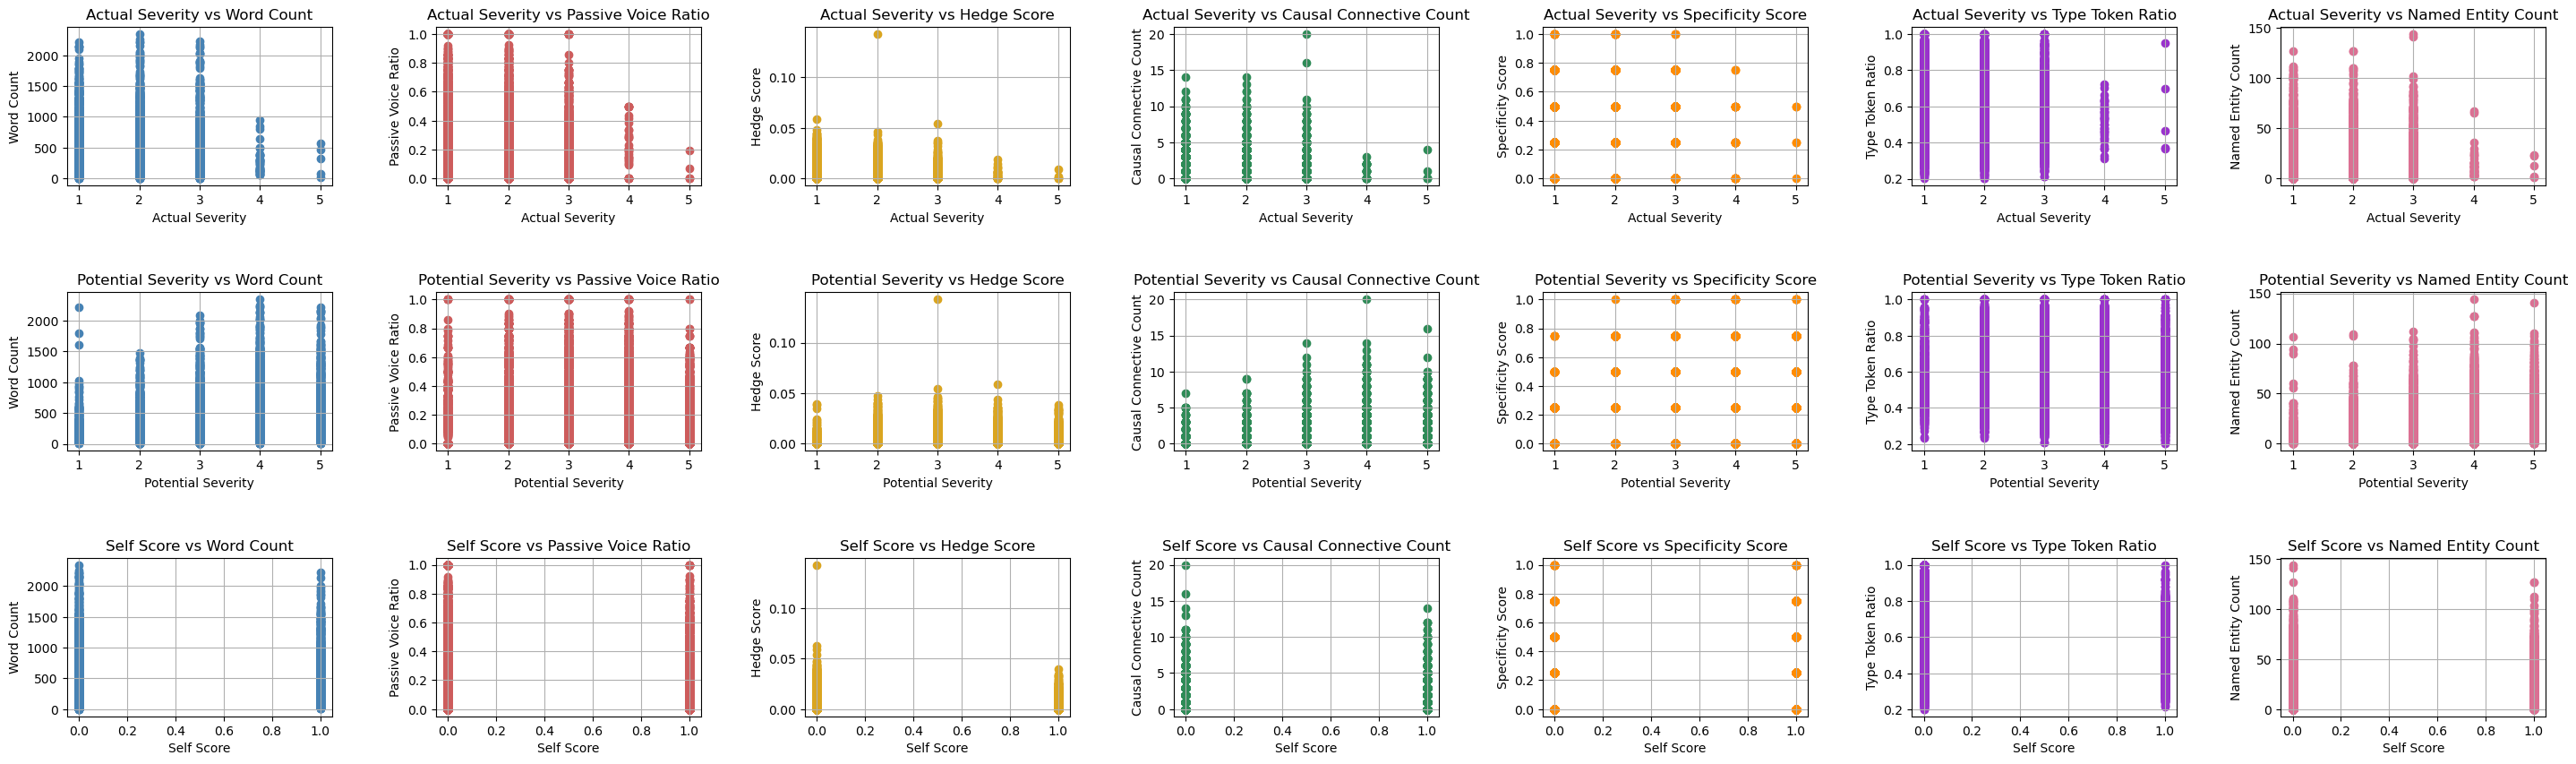

In [ ]:
# Chart the Data
from itertools import product

x1 = data['actual_severity']
x2 = data['potential_severity']
x3 = data['self_score']
y1 = data['word_count']
y2 = data['passive_voice_ratio']
y3 = data['hedge_score']
y4 = data['causal_connective_count']
y5 = data['specificity_score']
y6 = data['type_token_ratio']
y7 = data['named_entity_count']

x_data = list(zip([x1, x2, x3], ['Actual Severity', 'Potential Severity', 'Self Score']))
y_data = list(zip([y1, y2, y3, y4, y5, y6, y7],
                   ['Word Count', 'Passive Voice Ratio', 'Hedge Score', 'Causal Connective Count', 'Specificity Score', 'Type Token Ratio', 'Named Entity Count']))

colors = ['steelblue', 'indianred', 'goldenrod', 'seagreen',
          'darkorange', 'darkorchid', 'palevioletred',
         'steelblue', 'indianred', 'goldenrod', 'seagreen',
          'darkorange', 'darkorchid', 'palevioletred',
         'steelblue', 'indianred', 'goldenrod', 'seagreen',
          'darkorange', 'darkorchid', 'palevioletred']

combos = list(product(x_data, y_data))  # 8 (x, y) pairs, each carrying its own label

fig, axs = plt.subplots(nrows=3, ncols=7, figsize=(30, 10))

for ax, ((x, xlabel), (y, ylabel)), color in zip(axs.flat, combos, colors):
    ax.scatter(x, y, c=color, alpha=1)
    ax.set_title(f"{xlabel} vs {ylabel}")
    ax.grid(True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig.tight_layout(pad=6.0, h_pad=4.0, w_pad=4.0)
plt.show()

## Severity to Langauge Characteristics

In [ ]:
# Run the Linear Regressions

from IPython.display import HTML, display

IVs = 'actual_severity + potential_severity + self_score'
DVs = ['word_count', 'passive_voice_ratio', 'hedge_score', 'causal_connective_count', 'specificity_score', 'named_entity_count', 'type_token_ratio']
titles = [word.title() for word in DVs]

results_list = []
for y in DVs:
    res = smf.ols(f'{y} ~ {IVs}', data=data).fit()
    results_list.append(res)

# Wrap each summary's HTML in a grid cell
cells_html = "".join(
    f'<div style="padding:8px; font-size:11px;">'
    f'<div style="font-weight:bold; margin-bottom:4px;">{title}</div>'
    f'{res.summary().as_html()}</div>'
    for res, title in zip(results_list, titles)
)

grid_html = f"""
<div style="display:grid; grid-template-columns: repeat(4, 1fr); gap:12px;">
    {cells_html}
</div>
"""

display(HTML(grid_html))

